# Metrics Table by Dataset and Action

For the CARD model, the stochastic stage is a conditional diffusion process defined over the residual correction and conditioned only on the coarse future. Let $x_0 = R$ denote the clean residual and $x_t$ its noisy version at diffusion step $t$. The forward process defines $q(x_t \mid x_0, \hat{Y}^c)$, while the learned reverse process parameterizes $p_\theta(x_{t-1} \mid x_t, \hat{Y}^c)$. Iterative denoising yields $\hat{R} \sim p_\theta(R \mid \hat{Y}^c)$, and the final forecast is recovered as $\hat{Y} = \hat{Y}^c + \hat{R}$.

In [1]:

from pathlib import Path

import pandas as pd
from IPython.display import display

CSV_PATH = (Path.cwd() / 'results' / 'all_models_metrics_long.csv' if (Path.cwd() / 'results').exists() else Path.cwd().parent / 'results' / 'all_models_metrics_long.csv')
METRIC_COLUMNS = [
    'APD',
    'ADE',
    'FDE',
    'MMADE',
    'MMFDE',
    'CMD',
    'FID',
]
HIGHER_IS_BETTER = {'APD'}

df = pd.read_csv(CSV_PATH)
df['action_filter'] = df['action_filter'].fillna('')


BEST_STYLE = 'font-weight: bold; color: #0f5132; background-color: #d1e7dd;'
SECOND_STYLE = 'font-weight: 600; color: #664d03; background-color: #fff3cd;'


def format_model_name(model_name):
    model_name = str(model_name or '')
    if model_name in {'twostage_dct_diffusion', 'FiHard'}:
        return 'CARD'
    return model_name[:1].upper() + model_name[1:] if model_name else model_name


def build_metrics_table(dataset, action_filter=''):
    action_filter = '' if action_filter is None else str(action_filter)

    filtered = df.loc[
        (df['status'] == 'ok')
        & (df['dataset'] == dataset)
        & (df['action_filter'] == action_filter),
        ['model', *METRIC_COLUMNS],
    ].copy()

    if filtered.empty:
        raise ValueError(
            f'No rows found for dataset={dataset!r} and action_filter={action_filter!r}.'
        )

    filtered['model'] = filtered['model'].map(format_model_name)
    filtered = filtered.sort_values('model').reset_index(drop=True)

    def highlight_best_and_second(series):
        styles = ['' for _ in series]
        ascending = series.name not in HIGHER_IS_BETTER
        ranked = series.dropna().sort_values(ascending=ascending, kind='stable')
        unique_values = ranked.drop_duplicates().tolist()

        if unique_values:
            best_value = unique_values[0]
            for idx in series.index[series.eq(best_value)]:
                styles[idx] = BEST_STYLE

        if len(unique_values) > 1:
            second_value = unique_values[1]
            for idx in series.index[series.eq(second_value)]:
                styles[idx] = (styles[idx] + ' ' + SECOND_STYLE).strip()

        return styles

    styled = (
        filtered.style.format({metric: '{:.3f}' for metric in METRIC_COLUMNS})
        .apply(highlight_best_and_second, subset=METRIC_COLUMNS, axis=0)
    )
    return filtered, styled


In [2]:
dataset_filter = 'assembly'
action_filter = 'all'

if action_filter == 'all':
    available_actions = (
        df.loc[df['dataset'] == dataset_filter, 'action_filter']
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if not available_actions:
        raise ValueError(f'No rows found for dataset={dataset_filter!r}.')

    for current_action in available_actions:
        table, styled_table = build_metrics_table(dataset_filter, current_action)
        print(f"dataset={dataset_filter!r}, action_filter={current_action!r}, rows={len(table)}")
        display(styled_table)
else:
    table, styled_table = build_metrics_table(dataset_filter, action_filter)
    print(f"dataset={dataset_filter!r}, action_filter={action_filter!r}, rows={len(table)}")
    display(styled_table)


dataset='assembly', action_filter='attempt', rows=9


,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,5.688,1.644,1.769,1.651,1.766,0.041,0.399
1,comusion,9.365,0.719,0.979,0.816,0.992,0.005,0.296
2,dlow_cvae,7.634,0.884,1.102,0.938,1.108,0.013,0.165
3,gsps,10.461,0.778,1.070,0.863,1.084,0.011,0.501
4,humanmac,9.635,0.888,1.138,0.923,1.146,0.010,0.259
5,skeletondiffusion,7.149,1.022,1.305,1.058,1.313,0.012,0.357
6,FiHard,5.649,0.701,0.956,0.799,0.971,0.010,0.070
7,FiHard,5.792,0.698,0.950,0.797,0.966,0.009,0.044
8,FiHard,5.958,0.705,0.964,0.802,0.979,0.009,0.035


dataset='assembly', action_filter='pick', rows=9


,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,6.981,1.793,1.875,1.797,1.873,0.030,0.088
1,comusion,11.384,0.872,1.140,0.937,1.146,0.006,0.306
2,dlow_cvae,8.834,1.001,1.201,1.032,1.200,0.011,0.007
3,gsps,9.611,0.867,1.140,0.928,1.146,0.010,0.030
4,humanmac,11.604,1.101,1.346,1.121,1.345,0.008,0.183
5,skeletondiffusion,10.756,1.269,1.580,1.295,1.586,0.006,1.610
6,FiHard,7.368,0.828,1.083,0.897,1.092,0.006,0.000
7,FiHard,7.344,0.822,1.079,0.892,1.089,0.007,0.000
8,FiHard,7.016,0.816,1.078,0.887,1.087,0.007,0.000


dataset='assembly', action_filter='pick_up_screwd', rows=6


...

,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,6.292,1.678,1.736,1.685,1.733,0.034,0.163
1,comusion,9.438,0.802,1.084,0.878,1.090,0.004,0.000
2,dlow_cvae,8.654,0.999,1.235,1.037,1.235,0.016,0.281
3,gsps,10.145,0.844,1.148,0.913,1.153,0.010,0.150
4,humanmac,9.909,0.965,1.209,0.992,1.213,0.008,0.047
5,skeletondiffusion,8.681,1.320,1.663,1.341,1.666,0.007,1.522
6,FiHard,5.757,0.774,1.061,0.853,1.067,0.010,0.000
7,FiHard,6.611,0.776,1.055,0.857,1.062,0.008,0.000
8,FiHard,6.598,0.774,1.055,0.855,1.061,0.008,0.000
9,FiHard,6.598,0.774,1.055,0.855,1.061,0.008,0.000


dataset='assembly', action_filter='rotate', rows=11


,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,6.562,1.895,1.951,1.901,1.952,0.046,0.500
1,comusion,13.578,0.967,1.280,1.019,1.284,0.006,0.880
2,dlow_cvae,9.511,1.145,1.356,1.165,1.355,0.017,0.270
3,gsps,9.643,0.948,1.247,0.995,1.252,0.018,0.399
4,humanmac,13.266,1.201,1.503,1.215,1.506,0.011,0.718
5,skeletondiffusion,9.531,1.566,1.971,1.581,1.972,0.014,2.110
6,FiHard,7.447,0.923,1.234,0.976,1.237,0.013,0.221
7,FiHard,7.823,0.918,1.225,0.970,1.228,0.013,0.182
8,FiHard,7.439,0.910,1.222,0.963,1.225,0.013,0.172
9,FiHard,7.439,0.910,1.222,0.963,1.225,0.013,0.172


dataset='assembly', action_filter='unscrew', rows=11


,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID
0,belfusion,5.830,1.454,1.471,1.463,1.469,0.038,0.402
1,comusion,9.535,0.752,0.910,0.851,0.932,0.004,0.578
2,dlow_cvae,7.539,0.935,0.983,0.980,0.991,0.020,0.284
3,gsps,10.192,0.794,0.976,0.876,0.997,0.020,0.740
4,humanmac,8.294,0.879,1.035,0.914,1.045,0.018,0.410
5,skeletondiffusion,6.894,1.147,1.343,1.182,1.352,0.019,1.589
6,FiHard,5.751,0.723,0.871,0.828,0.898,0.010,0.114
7,FiHard,5.517,0.708,0.858,0.816,0.887,0.011,0.104
8,FiHard,5.719,0.709,0.858,0.818,0.887,0.009,0.080
9,FiHard,5.719,0.709,0.858,0.818,0.887,0.009,0.080


In [3]:

ABLATIONS_CSV_PATH = (Path.cwd() / 'results' / 'FiHard_ablations.csv' if (Path.cwd() / 'results').exists() else Path.cwd().parent / 'results' / 'FiHard_ablations.csv')

ablations_df = pd.read_csv(ABLATIONS_CSV_PATH)
ablations_df['action_filter'] = ablations_df['action_filter'].fillna('')
ablations_df['model'] = ablations_df['model'].fillna('')


def build_ablations_table(dataset, action_filter='', ablation_filter='all'):
    action_filter = '' if action_filter is None else str(action_filter)

    if ablation_filter is None:
        ablation_filter = 'all'

    if isinstance(ablation_filter, str):
        ablation_filter_label = ablation_filter
        selected_models = None if ablation_filter == 'all' else [ablation_filter]
    else:
        selected_models = [str(model) for model in ablation_filter]
        ablation_filter_label = selected_models

    mask = (
        (ablations_df['status'] == 'ok')
        & (ablations_df['dataset'] == dataset)
        & (ablations_df['action_filter'] == action_filter)
    )
    if selected_models is not None:
        mask &= ablations_df['model'].isin(selected_models)

    filtered = ablations_df.loc[mask, ['model', *METRIC_COLUMNS, 'notes']].copy()

    if filtered.empty:
        raise ValueError(
            f'No ablation rows found for dataset={dataset!r}, action_filter={action_filter!r}, and ablation_filter={ablation_filter_label!r}.'
        )

    filtered['model'] = filtered['model'].map(format_model_name)
    filtered = filtered.sort_values('model').reset_index(drop=True)

    def highlight_best_and_second(series):
        styles = ['' for _ in series]
        ascending = series.name not in HIGHER_IS_BETTER
        ranked = series.dropna().sort_values(ascending=ascending, kind='stable')
        unique_values = ranked.drop_duplicates().tolist()

        if unique_values:
            best_value = unique_values[0]
            for idx in series.index[series.eq(best_value)]:
                styles[idx] = BEST_STYLE

        if len(unique_values) > 1:
            second_value = unique_values[1]
            for idx in series.index[series.eq(second_value)]:
                styles[idx] = (styles[idx] + ' ' + SECOND_STYLE).strip()

        return styles

    styled = (
        filtered.style.format({metric: '{:.3f}' for metric in METRIC_COLUMNS})
        .apply(highlight_best_and_second, subset=METRIC_COLUMNS, axis=0)
    )
    return filtered, styled


# ablation_filter = ['FiHard', 'FiHard_gaussian_kernel_noise', 'FiHard_empirical_plus_theoretical_covariance', 'FiHard_empirical_temporal_mean_covariance']
ablation_filter = 'all'

if action_filter == 'all':
    available_ablation_actions = (
        ablations_df.loc[ablations_df['dataset'] == dataset_filter, 'action_filter']
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if not available_ablation_actions:
        raise ValueError(f'No ablation rows found for dataset={dataset_filter!r}.')

    for current_action in available_ablation_actions:
        ablations_table, styled_ablations_table = build_ablations_table(dataset_filter, current_action, ablation_filter)
        print(
            f"ablations | dataset={dataset_filter!r}, action_filter={current_action!r}, ablation_filter={ablation_filter!r}, rows={len(ablations_table)}"
        )
        display(styled_ablations_table)
else:
    ablations_table, styled_ablations_table = build_ablations_table(dataset_filter, action_filter, ablation_filter)
    print(
        f"ablations | dataset={dataset_filter!r}, action_filter={action_filter!r}, ablation_filter={ablation_filter!r}, rows={len(ablations_table)}"
    )
    display(styled_ablations_table)


ablations | dataset='assembly', action_filter='pick_up_screwd', ablation_filter='all', rows=24


,model,APD,ADE,FDE,MMADE,MMFDE,CMD,FID,notes
0,FiHard_base,7.548,0.893,1.106,0.932,1.109,0.010,0.087,baseline: exact configs/models/FiHard.yaml
1,FiHard_beta_power_15,6.933,0.900,1.126,0.937,1.126,0.012,0.191,ablation: increase spectral beta rate shaping power to 1.5
2,FiHard_coarse_dim_256,7.484,0.915,1.136,0.950,1.136,0.012,0.129,ablation: reduce FiHard denoiscoarseer hidden dimension to 256
3,FiHard_coarse_dim_64,7.221,0.897,1.117,0.936,1.119,0.011,0.136,ablation: reduce FiHard denoiscoarseer hidden dimension to 64
4,FiHard_denoiser_depth_4,7.263,0.892,1.110,0.930,1.113,0.012,0.138,ablation: reduce FiHard denoiser depth to 4
5,FiHard_denoiser_depth_8,7.132,0.889,1.110,0.928,1.114,0.012,0.126,ablation: increase FiHard denoiser depth to 8
6,FiHard_denoiser_dim_128,7.077,0.894,1.122,0.932,1.124,0.012,0.169,ablation: increase FiHard denoiser hidden dimension to 128
7,FiHard_denoiser_dim_512,7.090,0.871,1.090,0.912,1.093,0.007,0.023,ablation: increase FiHard denoiser hidden dimension to 512
8,FiHard_denoiser_dim_64,7.202,0.933,1.181,0.971,1.183,0.012,0.148,ablation: reduce FiHard denoiser hidden dimension to 64
9,FiHard_dhalf_gamma_05,6.829,0.886,1.106,0.925,1.108,0.012,0.149,ablation: weaken mobility scaling by using D_half with gamma=0.5


Found 68 eval sample bundles under /home/fagnelli/diffusion_hands_freq/out/diffusion_hands_runs


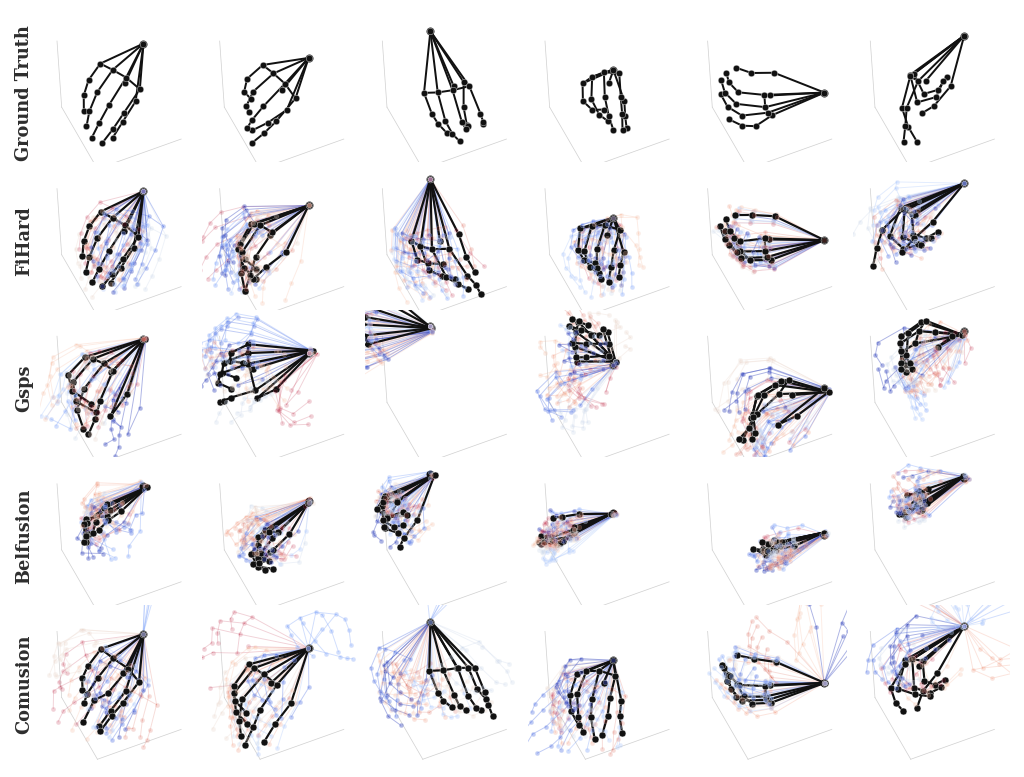

In [3]:

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

IEEE_SINGLE_COLUMN_WIDTH = 3.5
IEEE_DOUBLE_COLUMN_WIDTH = 7.16

PAPER_RC = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 8.5,
    'axes.labelsize': 8,
    'axes.titlesize': 8.5,
    'axes.linewidth': 0.6,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
}

PLOT_STYLE = {
    'gt_color': '#111111',
    'candidate_color_start': '#d8a600',
    'candidate_color_end': '#5f6670',
    'candidate_alpha_min': 0.18,
    'candidate_alpha_max': 0.42,
    'best_color': '#1f4e79',
    'joint_edge': '#f8f8f8',
    'axis_edge': '0.82',
    'label_color': '0.18',
}

CANDIDATE_CMAP = LinearSegmentedColormap.from_list(
    'candidate_yellow_to_grey',
    [PLOT_STYLE['candidate_color_start'], PLOT_STYLE['candidate_color_end']],
)

plt.rcParams.update(PAPER_RC)

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'results').exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from common.dataset_graphs import get_root_first_single_hand_graph, resolve_local_hand_graph_metadata

EVAL_SAMPLES_ROOT = PROJECT_ROOT / 'out' / 'diffusion_hands_runs'


def _display_model_name(model_name):
    model_name = str(model_name or '')
    if model_name in {'twostage_dct_diffusion', 'FiHard'}:
        return 'FiHard'
    return model_name[:1].upper() + model_name[1:] if model_name else model_name


def _normalize_model_filter(model_filter):
    if model_filter is None or model_filter == 'all':
        return None

    if isinstance(model_filter, str):
        selected_models = [model_filter]
    else:
        selected_models = [str(model_name) for model_name in model_filter]

    normalized = {model_name.strip().lower() for model_name in selected_models if str(model_name).strip()}
    if normalized & {'FiHard', 'twostage_dct_diffusion'}:
        normalized.update({'FiHard', 'twostage_dct_diffusion'})
    return normalized


def _matches_model_filter(model_name, model_filter):
    normalized = _normalize_model_filter(model_filter)
    if normalized is None:
        return True
    return (
        str(model_name or '').strip().lower() in normalized
        or _display_model_name(model_name).lower() in normalized
    )


def list_saved_eval_sample_files(root=EVAL_SAMPLES_ROOT):
    return sorted(root.glob('**/eval_samples.npz'))


def load_saved_eval_samples(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    payload = {key: data[key] for key in data.files if key != 'metadata_json'}
    metadata = {}
    if 'metadata_json' in data.files:
        metadata = json.loads(str(data['metadata_json']))
    pred = payload.get('pred')
    pred_all = payload.get('pred_all')
    if pred is not None and pred_all is not None and pred_all.ndim == 5 and pred.ndim == 4:
        if pred_all.shape[0] != pred.shape[0] and pred_all.shape[1] == pred.shape[0]:
            payload['pred_all'] = np.transpose(pred_all, (1, 0, 2, 3, 4))
    return payload, metadata


def collect_saved_eval_samples(root=EVAL_SAMPLES_ROOT, dataset=None, action_filter=None):
    bundles = []
    for npz_path in list_saved_eval_sample_files(root):
        payload, metadata = load_saved_eval_samples(npz_path)
        meta_dataset = metadata.get('dataset')
        meta_action = metadata.get('action_filter', '') or 'all'
        if dataset is not None and meta_dataset != dataset:
            continue
        if action_filter is not None and meta_action != action_filter:
            continue
        bundles.append({'path': npz_path, 'payload': payload, 'metadata': metadata})
    return bundles


def _select_latest_bundle_per_model(bundles):
    by_model = {}
    for bundle in bundles:
        model_name = bundle['metadata'].get('model', bundle['path'].parent.name)
        current = by_model.get(model_name)
        if current is None or bundle['path'].stat().st_mtime > current['path'].stat().st_mtime:
            by_model[model_name] = bundle
    return dict(sorted(by_model.items()))


def _sample_timestep_indices(num_frames, max_timesteps=10):
    max_timesteps = max(1, min(int(max_timesteps), int(num_frames)))
    if max_timesteps == num_frames:
        return np.arange(num_frames, dtype=int)
    return np.unique(np.round(np.linspace(0, num_frames - 1, max_timesteps)).astype(int))


def _hand_edges_for_dataset(dataset_name):
    if dataset_name is None:
        dataset_name = 'assembly'
    metadata = resolve_local_hand_graph_metadata(str(dataset_name).lower())
    return [tuple(edge) for edge in metadata.get('links', ())]


def _root_first_hand_edges_for_dataset(dataset_name):
    if dataset_name is None:
        dataset_name = 'assembly'
    metadata = get_root_first_single_hand_graph(str(dataset_name).lower())
    return [tuple(edge) for edge in metadata.get('links', ())]


def _model_uses_root_first_graph(model_name):
    model_name = str(model_name or '').lower()
    return model_name in {'dlow_cvae', 'humanmac'}


def _hand_edges_for_plot(model_name, dataset_name):
    use_root_first = _model_uses_root_first_graph(model_name)
    return _root_first_hand_edges_for_dataset(dataset_name) if use_root_first else _hand_edges_for_dataset(dataset_name)


def _prepare_hands_for_plot(hands_frame, model_name, dataset_name, hand_edges=None):
    hands_frame = np.asarray(hands_frame)
    if hands_frame.ndim == 2:
        hands_frame = hands_frame[None, ...]

    use_root_first = _model_uses_root_first_graph(model_name)
    if hand_edges is None:
        hand_edges = _hand_edges_for_plot(model_name, dataset_name)

    if use_root_first and hands_frame.shape[-2] == 20:
        root = np.zeros(hands_frame.shape[:-2] + (1, hands_frame.shape[-1]), dtype=hands_frame.dtype)
        hands_frame = np.concatenate([root, hands_frame], axis=-2)

    return hands_frame, hand_edges


def _compute_axis_box(points):
    points = np.asarray(points)
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = max(1e-6, 0.5 * np.max(maxs - mins))
    return center, radius


def _set_equal_axes(ax, points=None, axis_box=None):
    if axis_box is None:
        if points is None:
            raise ValueError('Either points or axis_box must be provided.')
        axis_box = _compute_axis_box(points)
    center, radius = axis_box
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)


def _style_hand_axis(ax, style=PLOT_STYLE, show_cartesian_axis=False):
    ax.grid(False)
    ax.set_facecolor('white')
    ax.set_box_aspect((1, 1, 1))
    if False:
        ax.set_xlabel('x', labelpad=-8, color=style['label_color'], fontsize=6)
        ax.set_ylabel('y', labelpad=-8, color=style['label_color'], fontsize=6)
        ax.set_zlabel('z', labelpad=-6, color=style['label_color'], fontsize=6)
        ax.tick_params(axis='x', colors=style['axis_edge'], labelsize=5, pad=-2)
        ax.tick_params(axis='y', colors=style['axis_edge'], labelsize=5, pad=-2)
        ax.tick_params(axis='z', colors=style['axis_edge'], labelsize=5, pad=-1)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_alpha(0.0)
        axis.pane.set_edgecolor(style['axis_edge'])
        if hasattr(axis, 'line'):
            axis.line.set_color(style['axis_edge'])
            axis.line.set_linewidth(0.35)


def _add_row_label(ax, label, style=PLOT_STYLE):
    ax.text2D(
        -0.10,
        0.5,
        label,
        transform=ax.transAxes,
        rotation=90,
        va='center',
        ha='center',
        color=style['label_color'],
        fontsize=8.5,
        fontweight='semibold',
    )


def _downsample_hands(hands_frame, max_hands_per_subplot=None):
    hands_frame = np.asarray(hands_frame)
    if hands_frame.ndim == 2:
        return hands_frame[None, ...]
    if max_hands_per_subplot is None:
        return hands_frame
    max_hands_per_subplot = max(1, int(max_hands_per_subplot))
    if hands_frame.shape[0] <= max_hands_per_subplot:
        return hands_frame
    keep_idx = np.linspace(0, hands_frame.shape[0] - 1, max_hands_per_subplot).round().astype(int)
    keep_idx = np.unique(keep_idx)
    return hands_frame[keep_idx]


def _find_best_candidate_index(pred_all_sample, target_sample, model_name=None, dataset_name=None):
    pred_all_sample, _ = _prepare_hands_for_plot(pred_all_sample, model_name=model_name, dataset_name=dataset_name)
    target_sample, _ = _prepare_hands_for_plot(target_sample, model_name=model_name, dataset_name=dataset_name)
    pred_all_sample = np.asarray(pred_all_sample)
    target_sample = np.asarray(target_sample)
    if pred_all_sample.ndim < 4:
        return None
    diffs = pred_all_sample - target_sample[None, ...]
    distances = np.linalg.norm(diffs, axis=-1).mean(axis=tuple(range(1, diffs.ndim - 1)))
    return int(np.argmin(distances))


def _plot_hand_frame(ax, hands_frame, hand_edges, title=None, hand_cmap=None, max_hands_per_subplot=32, fixed_color=None, best_idx=None, axis_box=None, view_angles=None, show_cartesian_axis=False, style=PLOT_STYLE):
    hands_frame = np.asarray(hands_frame)
    hands_frame = _downsample_hands(hands_frame, max_hands_per_subplot=max_hands_per_subplot)
    best_color = '#111111'

    if fixed_color is not None:
        hand_styles = [{'color': fixed_color, 'alpha': 1.0, 'linewidth': 0.95, 'size': 10, 'zorder': 3}] * hands_frame.shape[0]
    elif hands_frame.shape[0] == 1:
        hand_styles = [{'color': best_color, 'alpha': 1.0, 'linewidth': 1.05, 'size': 11, 'zorder': 4}]
    else:
        if hand_cmap is None:
            hand_cmap = plt.get_cmap('coolwarm_r')
        hand_colors = hand_cmap(np.linspace(0.0, 1.0, hands_frame.shape[0]))
        hand_alphas = np.linspace(style['candidate_alpha_min'], style['candidate_alpha_max'], hands_frame.shape[0])
        hand_styles = [
            {'color': hand_colors[idx], 'alpha': hand_alphas[idx], 'linewidth': 0.45, 'size': 5, 'zorder': 1}
            for idx in range(hands_frame.shape[0])
        ]
        if best_idx is not None and 0 <= int(best_idx) < hands_frame.shape[0]:
            hand_styles[int(best_idx)] = {'color': best_color, 'alpha': 1.0, 'linewidth': 1.05, 'size': 11, 'zorder': 4}

    draw_order = [idx for idx in range(hands_frame.shape[0]) if idx != best_idx]
    if best_idx is not None and 0 <= int(best_idx) < hands_frame.shape[0]:
        draw_order.append(int(best_idx))

    for hand_idx in draw_order:
        hand = hands_frame[hand_idx]
        hand_style = hand_styles[hand_idx]
        valid_edges = [(i, j) for i, j in hand_edges if i < hand.shape[0] and j < hand.shape[0]]
        for i, j in valid_edges:
            ax.plot(
                [hand[i, 0], hand[j, 0]],
                [hand[i, 1], hand[j, 1]],
                [hand[i, 2], hand[j, 2]],
                color=hand_style['color'],
                alpha=hand_style['alpha'],
                linewidth=hand_style['linewidth'],
                zorder=hand_style['zorder'],
            )
        ax.scatter(
            hand[:, 0],
            hand[:, 1],
            hand[:, 2],
            color=hand_style['color'],
            alpha=hand_style['alpha'],
            s=hand_style['size'],
            edgecolors=style['joint_edge'],
            linewidths=0.18,
            depthshade=False,
            zorder=hand_style['zorder'],
        )

    ax.scatter([0], [0], [0], color=style['gt_color'], s=8, depthshade=False, zorder=5)

    all_points = hands_frame.reshape(-1, 3)
    _set_equal_axes(ax, all_points, axis_box=axis_box)
    if view_angles is None:
        elev, azim = 45, 65
    else:
        azim, elev = view_angles
    ax.view_init(elev=elev, azim=azim)
    _style_hand_axis(ax, style=style, show_cartesian_axis=show_cartesian_axis)
    if title:
        ax.set_title(title, pad=1.5, color=style['label_color'], fontweight='semibold')


def visualize_saved_eval_eccv_layout(sample_specs, dataset=None, action_filter=None, frame_idx=-1, model_order=None, model_filter='all', max_hands_per_subplot=32):
    bundles = collect_saved_eval_samples(dataset=dataset, action_filter=action_filter)
    bundles_by_model = _select_latest_bundle_per_model(bundles)
    if not bundles_by_model:
        raise ValueError('No saved eval samples found for the requested filters.')

    if model_order is None:
        candidate_model_names = list(bundles_by_model.keys())
    else:
        candidate_model_names = [name for name in model_order if name in bundles_by_model]

    model_names = [name for name in candidate_model_names if _matches_model_filter(name, model_filter)]
    if not model_names:
        available_models = ', '.join(_display_model_name(name) for name in candidate_model_names)
        raise ValueError(f'No models matched model_filter={model_filter!r}. Available models: {available_models}')

    if not sample_specs:
        raise ValueError('sample_specs must contain at least one sample specification.')

    first_bundle = bundles_by_model[model_names[0]]
    first_payload = first_bundle['payload']
    dataset_name = first_bundle['metadata'].get('dataset', dataset or 'assembly')
    hand_edges_gt = _hand_edges_for_plot('ground_truth', dataset_name)

    num_future_frames = int(first_payload['target'].shape[1])
    resolved_frame_idx = int(frame_idx)
    if resolved_frame_idx < 0:
        resolved_frame_idx = num_future_frames + resolved_frame_idx
    if resolved_frame_idx < 0 or resolved_frame_idx >= num_future_frames:
        raise IndexError(f'frame_idx={frame_idx} resolved to {resolved_frame_idx}, but valid range is [0, {num_future_frames - 1}].')

    num_rows = 1 + len(model_names)
    num_cols = len(sample_specs)
    fig_width = IEEE_DOUBLE_COLUMN_WIDTH
    subplot_size = fig_width / max(num_cols + 0.28, 1)
    fig_height = max(IEEE_SINGLE_COLUMN_WIDTH, subplot_size * num_rows * 0.95)
    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(fig_width, fig_height),
        subplot_kw={'projection': '3d'},
        squeeze=False,
    )
    fig.patch.set_facecolor('white')

    gt_axis_boxes = {}
    for col_idx, sample_spec in enumerate(sample_specs):
        sample_idx = int(sample_spec['sample_idx'])
        view_angles = tuple(sample_spec.get('view_angles', (65, 45)))
        if sample_idx >= len(first_payload['target']):
            raise IndexError(f'sample_idx saved samples.')
        gt_frame, gt_edges = _prepare_hands_for_plot(
            first_payload['target'][sample_idx, resolved_frame_idx],
            model_name='ground_truth',
            dataset_name=dataset_name,
            hand_edges=hand_edges_gt,
        )
        gt_axis_boxes[sample_idx] = _compute_axis_box(gt_frame.reshape(-1, 3))
        gt_title = sample_spec.get('title')
        _plot_hand_frame(
            axes[0, col_idx],
            gt_frame,
            gt_edges,
            title=gt_title,
            max_hands_per_subplot=max_hands_per_subplot,
            fixed_color=PLOT_STYLE['gt_color'],
            axis_box=gt_axis_boxes[sample_idx],
            view_angles=view_angles,
            show_cartesian_axis=True,
        )

    _add_row_label(axes[0, 0], 'Ground Truth')

    for row_idx, model_name in enumerate(model_names, start=1):
        payload = bundles_by_model[model_name]['payload']
        model_dataset_name = bundles_by_model[model_name]['metadata'].get('dataset', dataset_name)
        hand_edges_model = _hand_edges_for_plot(model_name, model_dataset_name)
        pred_all = payload.get('pred_all')
        pred = payload.get('pred')
        for col_idx, sample_spec in enumerate(sample_specs):
            sample_idx = int(sample_spec['sample_idx'])
            view_angles = tuple(sample_spec.get('view_angles', (65, 45)))
            if sample_idx >= len(payload['target']):
                raise IndexError(
                    f'sample_idx={sample_idx} out of range for model={model_name!r} with {len(payload["target"])} saved samples.'
                )
            best_idx = None
            if pred_all is not None:
                best_idx = _find_best_candidate_index(
                    pred_all[sample_idx],
                    payload['target'][sample_idx],
                    model_name=model_name,
                    dataset_name=model_dataset_name,
                )
                hands_frame = pred_all[sample_idx, :, resolved_frame_idx]
            else:
                hands_frame = pred[sample_idx, resolved_frame_idx][None, ...]
            hands_frame, hand_edges_model = _prepare_hands_for_plot(
                hands_frame,
                model_name=model_name,
                dataset_name=model_dataset_name,
                hand_edges=hand_edges_model,
            )
            _plot_hand_frame(
                axes[row_idx, col_idx],
                hands_frame,
                hand_edges_model,
                max_hands_per_subplot=max_hands_per_subplot,
                best_idx=best_idx,
                axis_box=gt_axis_boxes[sample_idx],
                view_angles=view_angles,
                show_cartesian_axis=True,
            )

        _add_row_label(axes[row_idx, 0], _display_model_name(model_name))

    fig.subplots_adjust(left=0.08, right=0.995, top=0.95, bottom=0.03, wspace=-0.04, hspace=-0.06)
    return fig, axes


def visualize_saved_eval_grid(sample_idx=0, dataset=None, action_filter=None, max_timesteps=10, model_order=None, model_filter='all', max_hands_per_subplot=32):
    bundles = collect_saved_eval_samples(dataset=dataset, action_filter=action_filter)
    bundles_by_model = _select_latest_bundle_per_model(bundles)
    if not bundles_by_model:
        raise ValueError('No saved eval samples found for the requested filters.')

    if model_order is None:
        candidate_model_names = list(bundles_by_model.keys())
    else:
        candidate_model_names = [name for name in model_order if name in bundles_by_model]

    model_names = [name for name in candidate_model_names if _matches_model_filter(name, model_filter)]
    if not model_names:
        available_models = ', '.join(_display_model_name(name) for name in candidate_model_names)
        raise ValueError(f'No models matched model_filter={model_filter!r}. Available models: {available_models}')

    first_bundle = bundles_by_model[model_names[0]]
    first_payload = first_bundle['payload']
    if sample_idx >= len(first_payload["target"]):
        raise IndexError(
            f"sample_idx={sample_idx} out of range for {len(first_payload['target'])} saved samples."
        )

    dataset_name = first_bundle['metadata'].get('dataset', dataset or 'assembly')
    hand_edges_gt = _hand_edges_for_plot('ground_truth', dataset_name)

    num_future_frames = first_payload['target'].shape[1]
    timestep_indices = _sample_timestep_indices(num_future_frames, max_timesteps=max_timesteps)
    print(f'Sampled timesteps: {timestep_indices.tolist()}')
    num_rows = 1 + len(model_names)
    num_cols = len(timestep_indices)
    fig_width = IEEE_DOUBLE_COLUMN_WIDTH
    subplot_size = fig_width / max(num_cols + 0.35, 1)
    fig_height = max(IEEE_SINGLE_COLUMN_WIDTH, subplot_size * num_rows * 0.92)
    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(fig_width, fig_height),
        subplot_kw={'projection': '3d'},
        squeeze=False,
    )
    fig.patch.set_facecolor('white')

    gt_hands = first_payload['target'][sample_idx]
    gt_axis_boxes = {}
    for col_idx, frame_idx in enumerate(timestep_indices):
        ax = axes[0, col_idx]
        gt_frame, gt_edges = _prepare_hands_for_plot(gt_hands[frame_idx], model_name='ground_truth', dataset_name=dataset_name, hand_edges=hand_edges_gt)
        gt_axis_boxes[int(frame_idx)] = _compute_axis_box(gt_frame.reshape(-1, 3))
        gt_title = f't={frame_idx}'
        _plot_hand_frame(ax, gt_frame, gt_edges, title=gt_title, max_hands_per_subplot=max_hands_per_subplot, fixed_color=PLOT_STYLE['gt_color'], axis_box=gt_axis_boxes[int(frame_idx)])

    _add_row_label(axes[0, 0], 'Ground Truth')

    for row_idx, model_name in enumerate(model_names, start=1):
        payload = bundles_by_model[model_name]['payload']
        model_dataset_name = bundles_by_model[model_name]['metadata'].get('dataset', dataset_name)
        hand_edges_model = _hand_edges_for_plot(model_name, model_dataset_name)
        pred_all = payload.get('pred_all')
        pred = payload['pred']
        best_idx = None
        if pred_all is not None:
            best_idx = _find_best_candidate_index(pred_all[sample_idx], payload['target'][sample_idx], model_name=model_name, dataset_name=model_dataset_name)
        for col_idx, frame_idx in enumerate(timestep_indices):
            ax = axes[row_idx, col_idx]
            if pred_all is not None:
                hands_frame = pred_all[sample_idx, :, frame_idx]
            else:
                hands_frame = pred[sample_idx, frame_idx][None, ...]
            hands_frame, hand_edges_model = _prepare_hands_for_plot(hands_frame, model_name=model_name, dataset_name=model_dataset_name, hand_edges=hand_edges_model)
            _plot_hand_frame(ax, hands_frame, hand_edges_model, max_hands_per_subplot=max_hands_per_subplot, best_idx=best_idx, axis_box=gt_axis_boxes[int(frame_idx)])

        _add_row_label(axes[row_idx, 0], _display_model_name(model_name))

    action_name = first_bundle['metadata'].get('action_filter', action_filter or '') or 'all'
    fig.subplots_adjust(left=0.08, right=0.995, top=0.94, bottom=0.03, wspace=-0.02, hspace=-0.04)
    plt.show()


saved_eval_files = list_saved_eval_sample_files()
print(f'Found {len(saved_eval_files)} eval sample bundles under {EVAL_SAMPLES_ROOT}')

eccv_sample_specs = [
    {'sample_idx': 1, 'view_angles': (65, 45)},
    {'sample_idx': 2, 'view_angles': (65, 45)},
    {'sample_idx': 5, 'view_angles': (65, 45)},
    {'sample_idx': 6, 'view_angles': (65, 45)},
    {'sample_idx': 7, 'view_angles': (65, 45)},
    {'sample_idx': 9, 'view_angles': (65, 45)},
]

model_order = ['FiHard', 'gsps', 'belfusion', 'comusion']

# ECCV-style comparison: FiHard-winning samples as columns, models as rows, final prediction frame only.
# RGB candidate coloring is preserved from the original plotting style.
fig, axes = visualize_saved_eval_eccv_layout(
    sample_specs=eccv_sample_specs,
    dataset='assembly',
    action_filter='pick_up_screwd',
    frame_idx=-1,
    model_order=model_order,
    model_filter=model_order,
    max_hands_per_subplot=10,
)
plt.show()


dataset='assembly', ablation='FiHard_temporal_velocity_prior_q025', temporal_modes=30, spatial_modes=60, exponent range=[0.103, 3.327]


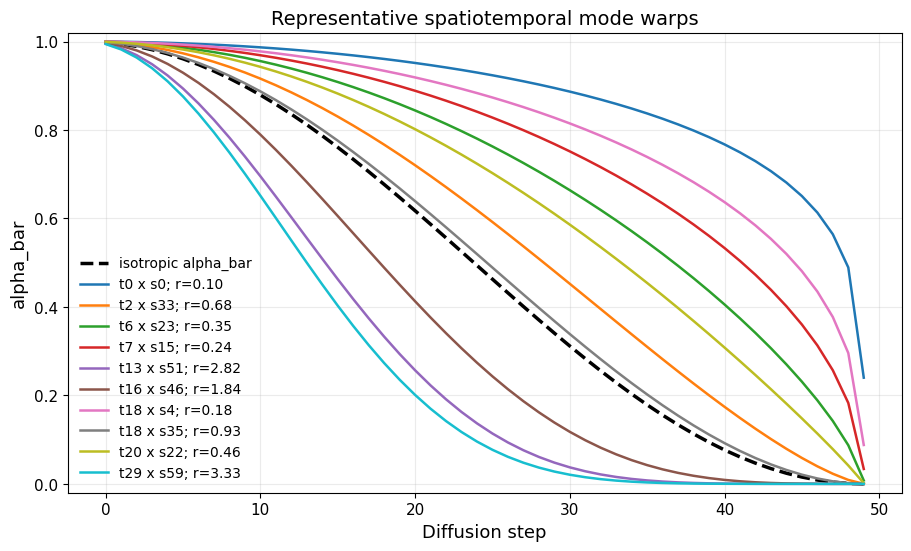

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

IEEE_SINGLE_COLUMN_WIDTH = 3.5
IEEE_DOUBLE_COLUMN_WIDTH = 7.16

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'axes.linewidth': 0.6,
    'legend.fontsize': 6,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'results').exists() else Path.cwd().parent
SPLINEEQNET_ROOT = PROJECT_ROOT / 'vendor' / 'splineeqnet'
for candidate in (PROJECT_ROOT, SPLINEEQNET_ROOT):
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from common.dataset_graphs import resolve_local_hand_graph_metadata
from models.FiHard import DiffusionSchedule, HandKinematicCovariance, _build_temporal_operator

CARD_CFG_PATH = PROJECT_ROOT / 'configs' / 'models' / 'FiHard.yaml'
ABLATION_CFG_PATH = PROJECT_ROOT / 'configs' / 'ablations' / 'FiHard_ablation.yaml'
dataset_name = 'assembly'
ablation_name = 'FiHard_temporal_velocity_prior_q025'
num_nodes = 21
pred_length = 30
num_highlight_modes = 10


def load_FiHard_cfg_with_ablation(
    FiHard_cfg_path=CARD_CFG_PATH,
    ablation_cfg_path=ABLATION_CFG_PATH,
    ablation_name=ablation_name,
):
    base_yaml = yaml.safe_load(Path(FiHard_cfg_path).read_text())
    cfg = dict(base_yaml['defaults'])

    ablation_yaml = yaml.safe_load(Path(ablation_cfg_path).read_text())
    ablation = ablation_yaml['models'][ablation_name]
    cfg.update(ablation.get('defaults', {}))
    return cfg, ablation.get('notes', '')


def _clamp_optional(values, min_value=None, max_value=None):
    if min_value is not None:
        values = torch.clamp(values, min=float(min_value))
    if max_value is not None:
        values = torch.clamp(values, max=float(max_value))
    return values


def compute_spatiotemporal_schedule_artifacts(
    dataset_name='assembly',
    ablation_name=ablation_name,
    FiHard_cfg_path=CARD_CFG_PATH,
    ablation_cfg_path=ABLATION_CFG_PATH,
    num_nodes=21,
    pred_length=30,
    num_highlight_modes=10,
):
    cfg, ablation_notes = load_FiHard_cfg_with_ablation(
        FiHard_cfg_path=FiHard_cfg_path,
        ablation_cfg_path=ablation_cfg_path,
        ablation_name=ablation_name,
    )
    graph_meta = resolve_local_hand_graph_metadata(dataset_name)

    schedule = DiffusionSchedule(
        steps=int(cfg['FiHard_diffusion_steps']),
        schedule=str(cfg.get('FiHard_beta_schedule', 'cosine')),
    )

    cov_builder = HandKinematicCovariance(
        num_nodes=num_nodes,
        wrist_index=int(graph_meta['wrist_index']),
        edges=graph_meta['links'],
        node_covariance_type=str(cfg['FiHard_node_covariance_type']),
        palm_var=float(cfg['FiHard_mobility_palm_var']),
        depth1_var=float(cfg['FiHard_mobility_depth1_var']),
        depth2_var=float(cfg['FiHard_mobility_depth2_var']),
        depth3plus_var=float(cfg['FiHard_mobility_depth3plus_var']),
        dhalf_gamma=float(cfg['FiHard_dhalf_gamma']),
        laplacian_tau=float(cfg.get('FiHard_graph_laplacian_tau', 1.0)),
        laplacian_alpha=float(cfg['FiHard_graph_laplacian_alpha']),
        laplacian_beta=float(cfg['FiHard_graph_laplacian_beta']),
        laplacian_normalized=bool(cfg.get('FiHard_graph_laplacian_normalized', True)),
    )

    cov = cov_builder.build_feature_covariance()
    spatial_eigvals, _ = torch.linalg.eigh(cov)
    covariance_jitter = float(cfg.get('FiHard_covariance_jitter', 1e-4))
    spatial_eigvals = torch.clamp(spatial_eigvals, min=max(covariance_jitter, 1e-8))

    temporal_operator_type = str(cfg.get('FiHard_temporal_operator_type', 'identity')).lower()
    if temporal_operator_type == 'identity' and bool(cfg.get('FiHard_temporal_anisotropy', False)):
        temporal_operator_type = 'dct_frequency'

    _, _, temporal_eigvals = _build_temporal_operator(
        length=int(pred_length),
        operator_type=temporal_operator_type,
        q=float(cfg.get('FiHard_temporal_anisotropy_q', 1.0)),
        velocity_weight=float(cfg.get('FiHard_temporal_velocity_weight', 1.0)),
        acceleration_weight=float(cfg.get('FiHard_temporal_acceleration_weight', 1.0)),
        jerk_weight=float(cfg.get('FiHard_temporal_jerk_weight', 1.0)),
        jitter=covariance_jitter,
        spectral_transform=str(cfg.get('FiHard_temporal_operator_spectral_transform', 'identity_shifted_power')),
    )

    lambda_st = temporal_eigvals.unsqueeze(1) * spatial_eigvals.unsqueeze(0)
    mean_lambda = torch.clamp(lambda_st.mean(), min=max(covariance_jitter, 1e-8))
    mode_rates = torch.pow(lambda_st / mean_lambda, float(cfg['FiHard_beta_matrix_power']))
    mode_rates = _clamp_optional(
        mode_rates,
        min_value=cfg.get('FiHard_beta_matrix_min_rate'),
        max_value=cfg.get('FiHard_beta_matrix_max_rate'),
    )

    iso_alpha_bars = schedule.alpha_bars.detach().cpu().numpy()
    mode_rates_np = mode_rates.detach().cpu().numpy()
    aniso_alpha_bars = np.power(iso_alpha_bars[:, None, None], mode_rates_np[None, :, :])

    steps = np.arange(len(iso_alpha_bars), dtype=float)
    flattened_order = np.argsort(mode_rates_np.reshape(-1))
    highlight_positions = np.linspace(
        0,
        len(flattened_order) - 1,
        num=min(num_highlight_modes, len(flattened_order)),
        dtype=int,
    )
    highlight_flat = np.unique(flattened_order[highlight_positions])
    highlight_temporal, highlight_spatial = np.unravel_index(highlight_flat, mode_rates_np.shape)

    return {
        'ablation_name': ablation_name,
        'ablation_notes': ablation_notes,
        'steps': steps,
        'iso_alpha_bars': iso_alpha_bars,
        'aniso_alpha_bars': aniso_alpha_bars,
        'spatial_eigvals': spatial_eigvals.detach().cpu().numpy(),
        'temporal_eigvals': temporal_eigvals.detach().cpu().numpy(),
        'mode_rates': mode_rates_np,
        'highlight_temporal': highlight_temporal,
        'highlight_spatial': highlight_spatial,
        'temporal_operator_type': temporal_operator_type,
    }


artifacts = compute_spatiotemporal_schedule_artifacts(
    dataset_name=dataset_name,
    ablation_name=ablation_name,
    num_nodes=num_nodes,
    pred_length=pred_length,
    num_highlight_modes=num_highlight_modes,
)

mode_rates = artifacts['mode_rates']
fig, ax_curve = plt.subplots(figsize=(IEEE_DOUBLE_COLUMN_WIDTH, 3.1), constrained_layout=True)
steps = artifacts['steps']
markevery = max(1, len(steps) // 8)
line_cycle = [
    ('0.15', '-', 'o'),
    ('0.35', '--', 's'),
    ('0.55', '-.', '^'),
    ('0.75', ':', 'D'),
    ('#0072B2', '-', 'v'),
    ('#D55E00', '--', 'P'),
    ('#009E73', '-.', 'X'),
    ('#CC79A7', ':', '*'),
    ('#56B4E9', '-', '<'),
    ('#E69F00', '--', '>'),
]

ax_curve.plot(
    steps,
    artifacts['iso_alpha_bars'],
    color='black',
    linestyle='--',
    linewidth=1.1,
    label='isotropic alpha_bar',
)
for line_idx, (temporal_idx, spatial_idx) in enumerate(zip(artifacts['highlight_temporal'], artifacts['highlight_spatial'])):
    rate = float(mode_rates[int(temporal_idx), int(spatial_idx)])
    color, linestyle, marker = line_cycle[line_idx % len(line_cycle)]
    ax_curve.plot(
        steps,
        artifacts['aniso_alpha_bars'][:, int(temporal_idx), int(spatial_idx)],
        color=color,
        linestyle=linestyle,
        linewidth=0.9,
        marker=marker,
        markersize=2.4,
        markevery=markevery,
        markerfacecolor='white',
        markeredgewidth=0.5,
        label=f't{int(temporal_idx)} x s{int(spatial_idx)}; r={rate:.2f}',
    )
ax_curve.set_xlabel('Diffusion step')
ax_curve.set_ylabel(r'$\bar{\alpha}$')
ax_curve.set_ylim(-0.02, 1.02)
ax_curve.grid(True, color='0.88', linewidth=0.4)
ax_curve.tick_params(axis='both', direction='in', length=3, width=0.6)
ax_curve.set_title('Representative spatiotemporal mode warps')
ax_curve.legend(loc='best', ncol=2, frameon=False, handlelength=2.2, columnspacing=0.8)

# fig.suptitle(
#     f"{artifacts['ablation_name']} ({artifacts['temporal_operator_type']})",
#     fontsize=15,
# )
print(
    f"dataset={dataset_name!r}, ablation={artifacts['ablation_name']!r}, "
    f"temporal_modes={mode_rates.shape[0]}, spatial_modes={mode_rates.shape[1]}, "
    f"exponent range=[{float(mode_rates.min()):.3f}, {float(mode_rates.max()):.3f}]"
)
plt.show()
